In [8]:
from scripts.util import vizualize_intrinsic_channels, apply_mask, pil_to_normalized_tensor
from scripts.rgbx_inference import build_rgbx_pipeline, infer_intrinsic_channels

In [2]:
pipe = build_rgbx_pipeline("/home/jsickert/adl4cv/rgb2x/model_cache")

/home/jsickert/miniconda3/envs/rgbx/lib/python3.9/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Fetching 12 files: 100%|██████████| 12/12 [00:48<00:00,  4.03s/it]
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading pipeline components...: 100%|██████████| 5/5 [00:05<00:00,  1.04s/it]


In [3]:
intrinsic_channels = infer_intrinsic_channels(
     "/home/jsickert/adl4cv/DATA/001/MVI_1810/image/1.png", pipe=pipe
)

100%|██████████| 50/50 [00:02<00:00, 23.80it/s]


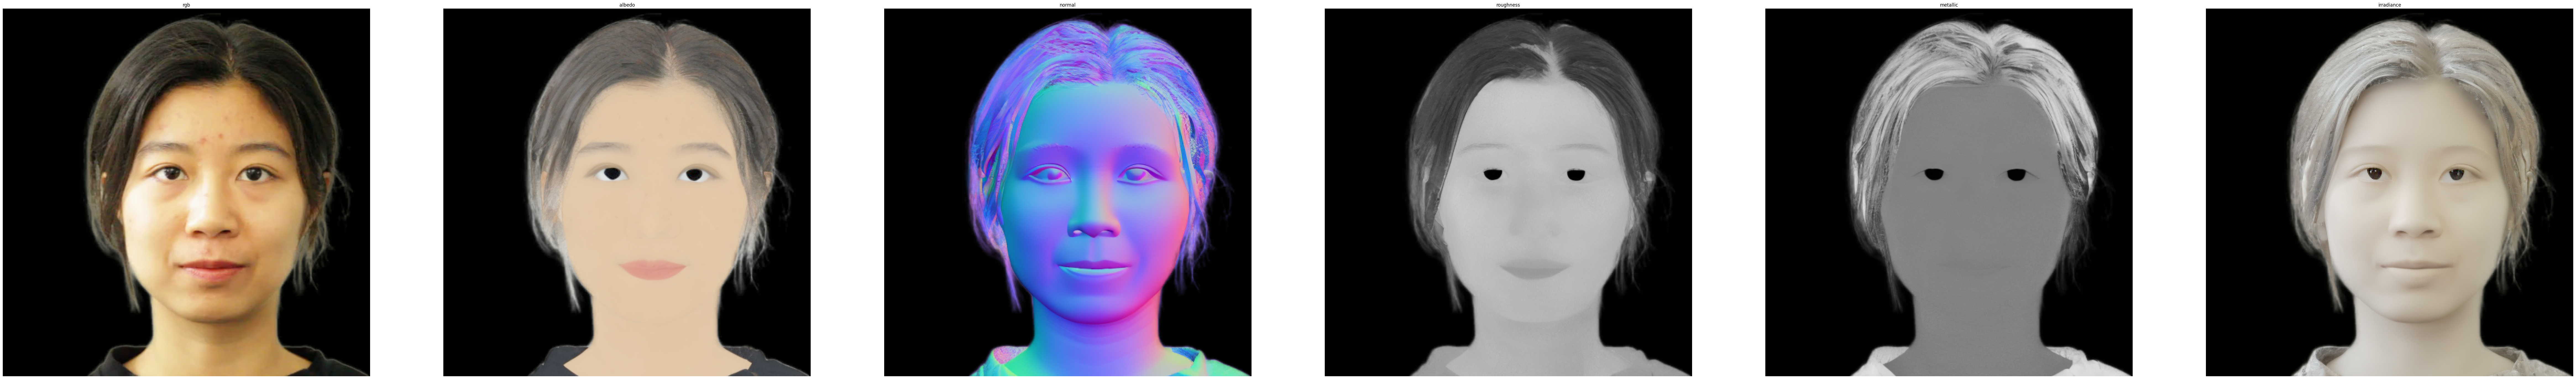

In [7]:
masked_intrinsic_channels = apply_mask(intrinsic_channels, mask_path="/home/jsickert/adl4cv/DATA/001/MVI_1810/mask/1.png")
vizualize_intrinsic_channels(masked_intrinsic_channels)

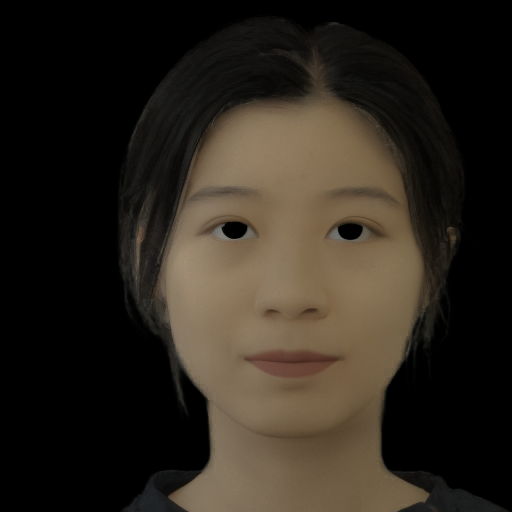

In [9]:
import torchvision

albedo = pil_to_normalized_tensor(masked_intrinsic_channels["albedo"])
irradiance = pil_to_normalized_tensor(masked_intrinsic_channels["irradiance"])
roughness = pil_to_normalized_tensor(masked_intrinsic_channels["roughness"])

diffuse_reconstruction = albedo * irradiance * roughness

torchvision.transforms.functional.to_pil_image(diffuse_reconstruction)